# PyTorch Lightning fine-tuning template

by Andrés Muñoz-Jaramillo

This notebook is meant to act as a template to train and use a surya model to implement DS application.

It focuses on the concept of defining a modified Surya model, loading its weigths, and using a PyTorch lightning training loop to train it

This notebook assumes familiarity with the concepts of datasets and dataloaders contained in the **_0_dataset_dataloader_template.ipynb_**

It doesn't require having seen the baselines template, but they are meant to complement each other.  **_In fact they are on purpose almost identical!!!_**

## Set your cuda visible device

**IMPORTANT:** Since we are sharing resources, please make sure that the cuda visible device you put here is the one assigned to your team and your machine.   

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
# Must be set BEFORE torch is imported: cuBLAS reads this once, when it initializes, so
# setting it later has no effect. It is what lets training.deterministic work without a
# cuBLAS warning on every run. (Restart the kernel if torch was already imported.)
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
os.environ["WANDB_NOTEBOOK_NAME"] = "2_finetune_2D-image-flip.ipynb"

import sys
from torch.utils.data import DataLoader

import torch
import yaml

import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger, WandbLogger

# Append base path.  May need to be modified if the folder structure changes.
# It gives the notebook access to the wokshop_infrastructure folder.
sys.path.append("../../")
 
# Append Surya path. May need to be modified if the folder structure changes.
# It gives the notebook access to surya's release code.

from workshop_infrastructure.utils import build_scalers  # Data scaling utilities for Surya stacks
from workshop_infrastructure.utils import apply_peft_lora
torch.set_float32_matmul_precision('medium')



## Load configuration

Surya was designed to read a configuration file that defines many aspects of the model
including the data it uses we use this config file to set default values that do not
need to be modified, but also to define values specific to our downstream application

In [3]:
# The config is the single source of truth. load_flare_config() parses it into a typed
# object, exactly as the training script 3_finetune_template_1D.py does, so the same YAML
# behaves identically here and in production. Notebook 0 walks through what it contains.
from downstream_apps.flare_forecast.configs import load_flare_config

cfg = load_flare_config("./configs/config_script.yaml")
print(f"Loaded config for job: {cfg.job_id}")


Loaded config for job: solar_flare_forecasting


## Download assets

The config says where the assets belong, so it is loaded first. `ensure_assets()` fetches only what is missing from HuggingFace, so re-running this is free.


In [4]:
# One implementation, shared by the notebooks, the training script and the
# download_*.sh wrappers: workshop_infrastructure/assets.py.
# Fine-tuning needs the pretrained backbone as well (~1.8 GB).
from workshop_infrastructure.assets import ensure_assets

ensure_assets(cfg, which=["scalers", "weights"])

# Now that scalers.yaml is guaranteed to be on disk, load it. build_scalers()
# accepts the resolved path directly.
scalers = build_scalers(info=cfg.data.scalers_path)
print(f"Loaded scalers for {len(scalers)} channels.")


Loaded scalers for 13 channels.


### Typed configuration, and how to extend it for your own task

`load_flare_config()` reads `configs/config_script.yaml` and returns a typed `TrainingConfig`.
This notebook and `3_finetune_template_1D.py` call the same function on the same file, so
there is no notebook-versus-script divergence to reason about.

| YAML section | Access in Python | Dataclass |
|---|---|---|
| `data:` | `cfg.data.*` | `FlareDataConfig` (this app) |
| `model:` | `cfg.model.*` | `ModelConfig` |
| `model.lora_config:` | `cfg.model.lora_config.*` | `LoraAdapterConfig` |
| `model.time_embedding:` | `cfg.model.time_embedding.*` | `TimeEmbeddingConfig` |
| `training:` | `cfg.learning_rate`, `cfg.batch_size`, … | `TrainingConfig` (flat) |
| `output:` | `cfg.output.*` | `OutputConfig` |
| `logging:` | `cfg.wandb_project`, `cfg.wandb_entity` | `TrainingConfig` (flat) |

**Everything except `FlareDataConfig` lives in `workshop_infrastructure/configs.py`** and is
shared by every downstream app. When you fork the template you do not copy that file. You
subclass `DataConfig` with your task's fields and bind `load_config` to it — the whole of
`downstream_apps/template/configs.py` is:

```python
@dataclass
class FlareDataConfig(DataConfig):
    flare_index_path: str = ""
    ds_time_column: str = "start_time"
    ds_time_tolerance: str = "4d"
    ds_match_direction: str = "forward"
    PATH_FIELDS = DataConfig.PATH_FIELDS + ("flare_index_path",)   # resolve it like a path

load_flare_config = partial(load_config, data_cls=FlareDataConfig)
```

Unknown keys are rejected rather than silently dropped: if you add a key to the YAML before
adding the field, you get an error naming the key and listing the valid ones.


## Define Downstream (DS) datasets

This child class takes as input all expected HelioFM parameters, plus additonal parameters relevant to the downstream application.  Here we focus in particular to the DS index and parameters necessary to combine it with the HelioFM index.

Another important component of creating a dataset class for your DS is normalization.  Here we use a log normalization on xray flux that will act as the output target.  Making log10(xray_flux) strictly positive and having 66% of its values between 0 and 1

In this case we will define both a training and a validation dataset using the indices pointed at in the config

**_Important:  In this notebook we sets max_number_of_samples=6 to potentially avoid going through the whole dataset as we explore it.  Keep in mind this for the future in case the database seems smaller than you expect_**


In [5]:
from downstream_apps.flare_forecast.datasets.flare_dataset import flare_Dataset

In [6]:
# build_helio_dataloaders() constructs the train and validation datasets and wraps them
# in DataLoaders. It fills in every generic argument (channels, temporal sampling, S3
# access, worker settings) from the config — see notebook 0 for what that block looks
# like written out. Only the flare-specific arguments are passed here, which is exactly
# the list you replace when you fork the template.
#
# It also handles two details that are easy to get wrong by hand: the validation set gets
# phase="val" (no random channel masking or flips), and only the training loader shuffles.
from workshop_infrastructure.datasets.builders import build_helio_dataloaders

train_data_loader, val_data_loader = build_helio_dataloaders(
    cfg,
    flare_Dataset,
    scalers=scalers,
    num_workers=0,          # fewer workers than the script: notebooks start faster
    #### Downstream (DS) specific parameters
    return_surya_stack=True,
    max_number_of_samples=3,
    ds_flare_index_path=cfg.data.flare_index_path,
    ds_time_column=cfg.data.ds_time_column,
    ds_time_tolerance=cfg.data.ds_time_tolerance,
    ds_match_direction=cfg.data.ds_match_direction,
)

batch_size = cfg.batch_size
print(f"train: {len(train_data_loader.dataset)} samples | "
      f"val: {len(val_data_loader.dataset)} samples | batch_size: {batch_size}")


train: 10 samples | val: 10 samples | batch_size: 2


Training and validation get separate datasets and dataloaders. They differ only in the index they read and in `phase`: `phase="val"` turns off the random channel masking and vertical flips used for training augmentation.

The loaders use `multiprocessing_context="spawn"` — the dataset holds an S3 client that does not survive `fork`, and spawn also avoids lockups in shared environments.


In [7]:
# Inspect a single batch to confirm shapes before building the model.
batch = next(iter(train_data_loader))
print({k: (tuple(v.shape) if hasattr(v, "shape") else type(v).__name__) for k, v in batch.items()})


{'ts': (2, 13, 2, 4096, 4096), 'time_delta_input': (2, 2), 'forecast': (2, 13, 1, 4096, 4096), 'lead_time_delta': (2, 1), 'ground_truth': (2,), 'ds_index': 'list', 'was_flipped': (2,)}


## Initialize the HelioSpectformer model

This is the main difference beteween the notebook that trains the simple model and the one that fine-tunes Surya.  

In the case of the finetuning exercise one of the main differences between DS applications is the dimensionality of the output.  In this notebook we use a modified HelioSpectformer that projects into a 1D space. 

IMPORTANT: If your DS application is 2D you need to use the HelioSpectformer2D. 
--> WE NEED 2D. 

(can always go back to  HelioSpectformer1D if needed)

In [7]:
from workshop_infrastructure.models.finetune_models import HelioSpectformer2D

/home/jovyan/envs/surya_ws/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Now the config file really comes into bear. The Spectformer has a metric ton of hyperparameters

In [8]:
# HelioSpectformer2D has a long list of architecture arguments, and all of them come
# straight from the model: section of the config. from_config() does that mapping, so the
# backbone can never drift out of sync with the checkpoint it is about to load.
#
# Arguments that are not part of ModelConfig (dtype, the head's output shape, and anything
# from the training: section) are passed as explicit overrides.
#
# ft_out_chans / ft_unembedding_type are the 2D head's knobs. There is no num_outputs:
# that is a 1D concept ("how many scalars to regress"), and passing it is a TypeError.
model = HelioSpectformer2D.from_config(
    cfg.model,
    ft_out_chans=len(cfg.data.channels),   # 13 -> output is (B, 13, 4096, 4096)
    ft_unembedding_type="linear",
    dtype=cfg.dtype,
    use_latitude_in_learned_flow=cfg.use_latitude_in_learned_flow,
)

## Load model weights

Here we load the pre-trained checkpoint and load the weights.  The exercise of loading follows the idea of us as many of the weights as possible.  This is accomplished through the filtered_checkpoint_state.   It checks to see if the pretrained model's layers match those of your finetuning architecture.   It also checks that all your dimensions across layers check out.   If something does not work those paramameters are left in their random initialization. 

In [9]:
# The checkpoint was saved from HelioSpectFormer directly, so its keys are flat
# (e.g. "embedding.proj.weight"), while the fine-tuning model nests the backbone under
# "backbone.*". load_pretrained_weights() tries both spellings and reports how many
# tensors matched — a low count means the architecture does not match the checkpoint.
from workshop_infrastructure.utils import load_pretrained_weights

load_pretrained_weights(model, cfg.model.pretrained_path)


Loading pretrained weights from /home/jovyan/tmp/surya_workshop/downstream_apps/flare_forecast/assets/surya.366m.v1.pt.


Loaded 157 / 159 pretrained weights.


## To LoRA or not to Lora

This cell gives you two options.  On the one hand we have the classic freezing of the backbone (the initial layers of the model).   On the other hand we have the use of a LoRA.

LoRas have been a remarkable addition to our arsenal of models.   They have the advantage of keeping pretty much the entire model intact and only add broad modifications to weights as needed.

In [10]:
# Three fine-tuning regimes, all selected from the model: section of the config:
#
#   use_lora: true                          -> LoRA adapters on attention + FFN (default)
#   use_lora: false, freeze_backbone: true  -> linear probe: only the head trains
#   use_lora: false, freeze_backbone: false -> full fine-tuning of all 366M parameters
#
# 3_finetune_template_1D.py applies exactly this logic in build_model().
if cfg.model.freeze_backbone:
    for name, param in model.named_parameters():
        if name.startswith("backbone."):
            param.requires_grad = False

if cfg.model.use_lora:
    model = apply_peft_lora(model, cfg.model.lora_config)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,} ({100 * trainable / total:.2f}%)")


Applying PEFT LoRA: r=8, alpha=8, dropout=0.1, modules=['q_proj', 'v_proj', 'k_proj', 'out_proj', 'fc1', 'fc2']


[LoRA] Adapted modules (20):
[LoRA]   backbone.backbone.blocks_attention.0.mlp.fc1
[LoRA]   backbone.backbone.blocks_attention.0.mlp.fc2
[LoRA]   backbone.backbone.blocks_attention.1.mlp.fc1
[LoRA]   backbone.backbone.blocks_attention.1.mlp.fc2
[LoRA]   backbone.backbone.blocks_attention.2.mlp.fc1
[LoRA]   backbone.backbone.blocks_attention.2.mlp.fc2
[LoRA]   backbone.backbone.blocks_attention.3.mlp.fc1
[LoRA]   backbone.backbone.blocks_attention.3.mlp.fc2
[LoRA]   backbone.backbone.blocks_attention.4.mlp.fc1
[LoRA]   backbone.backbone.blocks_attention.4.mlp.fc2
[LoRA]   backbone.backbone.blocks_attention.5.mlp.fc1
[LoRA]   backbone.backbone.blocks_attention.5.mlp.fc2
[LoRA]   backbone.backbone.blocks_attention.6.mlp.fc1
[LoRA]   backbone.backbone.blocks_attention.6.mlp.fc2
[LoRA]   backbone.backbone.blocks_attention.7.mlp.fc1
[LoRA]   backbone.backbone.blocks_attention.7.mlp.fc2
[LoRA]   backbone.backbone.blocks_spectral_gating.0.mlp.fc1
[LoRA]   backbone.backbone.blocks_spectral_gati

We can now test that this model manipulates a batch as expected and returns an estimate of flare intensity as we did for the simple baseline.

We pass the input stack 'ts' to the model to transform it into our regression output.   Note that since this model was trained for a different task, it's likely it won't perform very well.  As with the simple baseline, this only acts as a test that our model forward doesn't have dimension problems.

Dimension problemns are the dominant source of error in this kind of work.

Note that our output has now the size of our batch.

In [11]:
batch = next(iter(train_data_loader))
output = model.forward(batch)  # Get rid of singleton dimension
output

tensor([[[[ 4.3949e-01,  5.3887e-02,  8.1524e-01,  ...,  2.6019e-01,
            8.7490e-01, -7.5098e-01],
          [-4.1558e-01, -3.4904e-01, -9.7428e-01,  ..., -1.3372e-01,
           -4.5156e-02, -1.1451e-01],
          [ 4.1188e-01, -8.5980e-02, -5.7360e-01,  ..., -6.5276e-02,
           -1.1797e-01, -4.0871e-01],
          ...,
          [ 9.5648e-02, -5.0072e-01,  7.3232e-01,  ...,  4.2645e-02,
           -2.6213e-01, -1.9341e-01],
          [ 3.6423e-01, -4.0562e-01, -4.8221e-01,  ..., -8.5957e-01,
            9.4293e-02,  1.4219e-01],
          [ 8.0566e-03, -9.8458e-02,  7.6204e-01,  ..., -1.9113e-01,
           -5.3274e-01,  3.2729e-01]],

         [[-9.4620e-01,  7.6401e-02,  7.7120e-01,  ...,  1.4671e-02,
           -5.3212e-01,  1.8424e-01],
          [-3.3150e-01, -9.0098e-02, -1.8819e-01,  ...,  1.0100e+00,
            7.0564e-01,  7.3455e-01],
          [ 1.8886e-01, -6.0364e-01,  9.4755e-02,  ...,  2.9882e-01,
            1.4063e-01,  7.8432e-01],
          ...,
     

## Define your metrics

Metrics are a very important part of training AI models.   They provide your models with the quantitification of error, which in turn shifts the weights towards better pefrorming models.  They also provide a way for you to monitor performance, identify overfitting, and quantify value added. 

We now initialize the metrics class which allows you to control what metrics do you want to use as "loss" (i.e. the metrics that backpropagate through your model) and which ones for monitoring performance.  As with other components, this takes the form of a loaded module that can be later use in a training script

In [13]:
from downstream_apps.flare_forecast.metrics.flare_metrics import FlareMetrics

In [14]:
train_loss_metrics = FlareMetrics("train_loss")
# val_loss is the quantity logged as "val_loss" and used to pick the best checkpoint.
# It defaults to the same MSE as train_loss — override FlareMetrics.val_loss to change it.
val_loss_metrics = FlareMetrics("val_loss")
train_evaluation_metrics = FlareMetrics("train_metrics")
# Reported only: val_metrics do NOT influence checkpoint selection.
validation_evaluation_metrics = FlareMetrics("val_metrics")

Now they can be evaluated in our model's output and our ground truth.   First the loss that actually will backpropagate, in this case Mean Squared Errror

In [17]:
# batch["forecast"] is (B, 13, 1, 4096, 4096) — the 1 is the lead-time axis.
# The model outputs (B, 13, 4096, 4096), so drop it. Valid only because rollout_steps: 0
# gives exactly one target frame.
target = batch["forecast"][:, :, 0].float()
train_loss_metrics(output, target)

({'mse': tensor(1.1731, grad_fn=<MseLossBackward0>)}, [1])

Then a training evaluation that will not backpropagate and inform our model, but that we can keep an eye on. Note that reporting lots of metrics during training will slow the training process.  I'm including it her as an example, but oftentimes is better to put the diagnostics only in the validation evaluation metrics.

Here we are caclulating the Root Relative Squared Error https://lightning.ai/docs/torchmetrics/stable/regression/rse.html 

A value below one means the prediction is better than predicting the average.  It is unlikely that this metric will be lower than one with a randomly initialized model

In [18]:
train_evaluation_metrics(output, target)

({'rrse': tensor(1.1868)}, [1])

In the validation evaluation metrics we report both MSE and RRSE

In [19]:
validation_evaluation_metrics(output, target)

({'mse': tensor(1.1731), 'rrse': tensor(1.1868)}, [1, 1])

## Define your PyTorch ligthning module

In this workshop we will use PyTorch lightning to train our models.  PyTorch lighting reduces the amount of code required to implement a training loop in comparison to PyTorch (at the expense of control and versatility).  

Opening the FlareLightningModule shows a simple Lightning model implementation.  It consists of:

- An initialization of the class (metrics, model, and learning rate).
- The forward code that runs evaluation of the model.
- Training and validation steps.
- Configuration of optimizers.

**_Note that it is the same Lightning module we used for the baseline!!_**

In [15]:
from downstream_apps.flare_forecast.lightning_modules.pl_flare_baseline import FlareLightningModule

In [16]:
class Flare2DLightningModule(FlareLightningModule):
    """FlareLightningModule with a 2D image target instead of a scalar label."""

    @staticmethod
    def _target(batch):
        fc = batch["forecast"]
        assert fc.shape[2] == 1, (
            f"expected one target frame, got {fc.shape[2]}. Set training.rollout_steps: 0."
        )
        return fc[:, :, 0].float()          # (B, C, H, W)

    def _step(self, batch, stage):
        target = self._target(batch)
        if self.preprocess_fn is not None:
            batch = self.preprocess_fn(batch)
        output = self(batch)

        loss_fn = self.training_loss if stage == "train" else self.validation_loss
        eval_fn = self.training_evaluation if stage == "train" else self.validation_evaluation

        losses, weights = loss_fn(output, target)
        loss = self._combine_losses(losses, weights)
        self.log(f"{stage}_loss", loss, prog_bar=True, batch_size=self.batch_size, sync_dist=True)
        for k, v in losses.items():
            self.log(f"{stage}_loss_{k}", v, batch_size=self.batch_size, sync_dist=True)

        mets, mw = eval_fn(output, target)
        if len(mw) > 0:
            for k, v in mets.items():
                self.log(f"{stage}_metric_{k}", v, batch_size=self.batch_size, sync_dist=True)
        return loss

    def training_step(self, batch, batch_idx):   return self._step(batch, "train")
    def validation_step(self, batch, batch_idx): self._step(batch, "val")

## Set your global seeds

Since training AI models generally uses stochastic gradient descent, it is a good idea to fix your random seeds so that your training exercise is reproducible.    

In [17]:
L.seed_everything(42, workers=True)

Seed set to 42


42

## Intialize Lightning module

Now we properly initalize the Lightning module to enable training, including passing the dictionary of metrics

In [18]:
metrics = {
    'train_loss': train_loss_metrics,
    'val_loss': val_loss_metrics,
    'train_metrics': train_evaluation_metrics,
    'val_metrics': validation_evaluation_metrics,
}

lit_model = Flare2DLightningModule(model, metrics, lr=cfg.learning_rate, batch_size=batch_size)


## Logging

In order to properly compare experiments against each other, it is very useful to log evaluation metrics in a place where they can be compared against other training runs.  In this workshop we will use Weights and Biases (WandB). 

The first time you run WandB in a machine it will ask you to login to WandB.  You should have received an invitation to our project.  In order to login you must:

- Select option 2 (existing account).   In VScode the dialog opens a box at the top of your screen.
- Click on get API Key (this will open a browser).
- Generate API Key.
- Paste it in the dialog box at the top of your VSCode

In [19]:
project_name = cfg.wandb_project
from datetime import datetime
run_name = f"flare_flip_finetune_{datetime.now():%m%d_%H%M}"

wandb_logger = WandbLogger(
    entity=cfg.wandb_entity,  # set wandb_entity in the config; null = personal account
    project=project_name,
    name=run_name,
    log_model=False,
    save_dir="./jpereira/wandb/wandb_tmp",
)

csv_logger = CSVLogger("runs", name=project_name)


## Initialize trainer

With the loggers done, now the trainer needs to be defined.  The trainer defines several properties of your training run. Here we define:

- The max number of epochs (one epoch represents your model seeing your entire training dataset).
- Define where the training run will take place (auto uses the GPU if possible, if not, CPU).
- The loggers.
- The callbacks (here we save the model with the lowest validation loss).
- Logging frequency (because we are working with a small dataset it needs to be small).


**Note that in this notebook we also set a mixed precision to reduce the model's footprint in memory.**

In [20]:
max_epochs = 2

# -------------------------------------------------------------------------
# Trainer
# -------------------------------------------------------------------------
trainer = L.Trainer(
    max_epochs=max_epochs,
    accelerator="auto",
    devices="auto",
    precision="bf16-mixed", 
    logger=[wandb_logger, csv_logger],
    callbacks=[
        ModelCheckpoint(
            monitor="val_loss",
            mode="min",
            save_top_k=1,
        )
    ],
    log_every_n_steps=2,
)

Using bfloat16 Automatic Mixed Precision (AMP)


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


## Fit the model

Finally we fit the model.  We pass the Lighting module, and our dataloaders.

In [21]:
trainer.fit(lit_model, train_data_loader, val_data_loader)

wandb: WARNING The anonymous setting has no effect and will be removed in a future version.


wandb: Currently logged in as: jperei4 (surya-ws2) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


/home/jovyan/envs/surya_ws/lib/python3.12/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name  | Type      | Params | Mode  | FLOPs
----------------------------------------------------
0 | model | PeftModel | 371 M  | train | 0    
----------------------------------------------------
5.3 M     Trainable params
366 M     Non-trainable params
371 M     Total params
1,485.909 Total estimated model params size (MB)
377       Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

/home/jovyan/envs/surya_ws/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=2` reached.


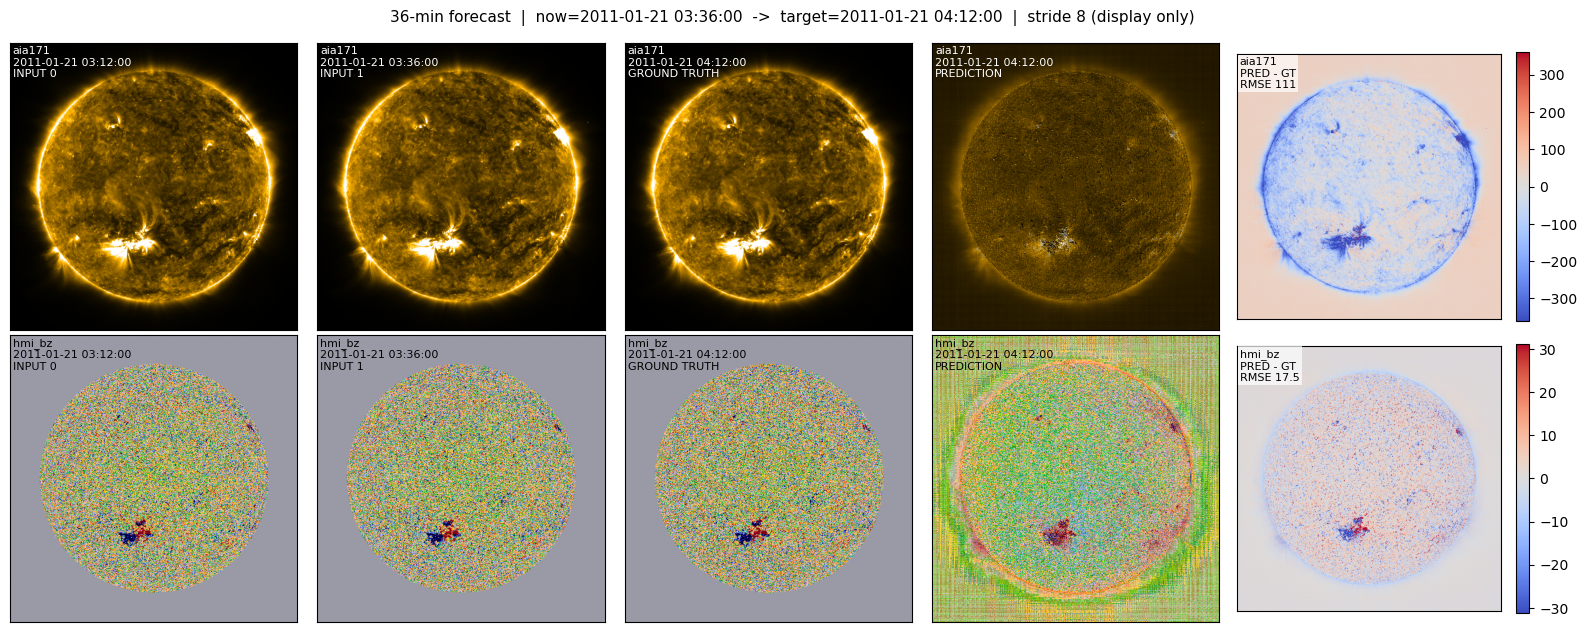

In [22]:
# ============================================================================
# What the model SHOULD predict vs. what it DOES predict.
# One sample only: a 13x4096x4096 fp32 array is 872 MB, so never plot a batch.
# STRIDE downsamples for display. inverse_transform_data is elementwise per
# channel, so striding first is exact -- but all 13 channels must stay present,
# because it indexes per-channel stats (that is why ft_out_chans=13 matters).
# ============================================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import sunpy.visualization.colormaps as cm          # registers sdoaia171, hmimag, ...
from torch.utils.data._utils.collate import default_collate

CHANNELS_TO_PLOT = ["aia171", "hmi_bz"]
STRIDE = 8          # 4096 -> 512 for display
FACTOR = 1          # 99th-percentile multiplier

ds = val_data_loader.dataset
ch_idx = {c: cfg.data.channels.index(c) for c in CHANNELS_TO_PLOT}

item = ds[0]
lit_model = lit_model.to("cuda").eval()             # Lightning moves it back to CPU after fit
with torch.no_grad(), torch.autocast("cuda", dtype=torch.bfloat16):
    b = default_collate([item])
    b = {k: (v.to("cuda") if torch.is_tensor(v) else v) for k, v in b.items()}
    out = lit_model(b)                              # (1, 13, 4096, 4096)
    # Stride on the GPU, then copy: 13 MB back to host instead of 872 MB.
    pred_n = out[0, :, ::STRIDE, ::STRIDE].float().contiguous().cpu().numpy()
del out, b; torch.cuda.empty_cache()

_c = lambda a: np.ascontiguousarray(a)              # numba wants C-contiguous
pred = ds.inverse_transform_data(pred_n)
gt   = ds.inverse_transform_data(_c(item["forecast"][:, 0, ::STRIDE, ::STRIDE]))
ins  = [ds.inverse_transform_data(_c(item["ts"][:, t, ::STRIDE, ::STRIDE]))
        for t in range(item["ts"].shape[1])]

# helio.py: the LAST sorted input offset is the "now" frame.
ref  = pd.Timestamp(ds.valid_indices[0])
now  = ref + pd.Timedelta(minutes=sorted(cfg.data.time_delta_input_minutes)[-1])
t_in = [now - pd.Timedelta(minutes=round(float(h) * 60)) for h in item["time_delta_input"]]
t_gt = now - pd.Timedelta(minutes=round(float(item["lead_time_delta"][0]) * 60))

def _lim(a, factor=1):
    nz = a[a != 0]
    return float(np.percentile(nz, 99) * factor) if nz.size else 1.0

def _show(ax, img, channel, label, lim):
    """GT and prediction MUST share `lim`, or the comparison is meaningless."""
    if "hmi" not in channel:
        ax.imshow(img, cmap=f"sdo{channel}", vmin=0, vmax=lim); fc = "w"
    else:
        ax.imshow(img, cmap="coolwarm" if "_v" in channel else "hmimag",
                  vmin=-lim, vmax=lim); fc = "k"
    ax.text(0.01, 0.99, label, transform=ax.transAxes, ha="left", va="top",
            color=fc, fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])

n_in = len(ins)
cols = n_in + 3                                     # inputs + GT + pred + diff
fig, axes = plt.subplots(len(CHANNELS_TO_PLOT), cols,
                         figsize=(3.2 * cols, 3.2 * len(CHANNELS_TO_PLOT)),
                         squeeze=False)
for r, c in enumerate(CHANNELS_TO_PLOT):
    n = ch_idx[c]
    lim = _lim(gt[n], FACTOR)                       # scale set by GT, reused for pred
    for t in range(n_in):
        _show(axes[r][t], ins[t][n], c, f"{c}\n{t_in[t]}\nINPUT {t}", lim)
    _show(axes[r][n_in],     gt[n],   c, f"{c}\n{t_gt}\nGROUND TRUTH", lim)
    _show(axes[r][n_in + 1], pred[n], c, f"{c}\n{t_gt}\nPREDICTION",   lim)

    d = pred[n] - gt[n]
    dl = float(np.percentile(np.abs(d), 99)) or 1.0
    ax = axes[r][n_in + 2]
    im = ax.imshow(d, cmap="coolwarm", vmin=-dl, vmax=dl)
    rmse = float(np.sqrt((d ** 2).mean()))
    ax.text(0.01, 0.99, f"{c}\nPRED - GT\nRMSE {rmse:.3g}", transform=ax.transAxes,
            ha="left", va="top", fontsize=8,
            bbox=dict(fc="w", ec="none", alpha=0.7, pad=1.5))
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle(f"36-min forecast  |  now={now}  ->  target={t_gt}  "
             f"|  stride {STRIDE} (display only)", fontsize=11)
plt.tight_layout(); plt.show()

FLARE EVENT      : M2.0   
  start_time     : 2010-06-12T00:30:00
  peak_time      : 2010-06-12T00:57:00
  end_time       : 2010-06-12T01:02:00
 
 
ds_time_column = 'peak_time'  ->  2010-06-12 00:57:00
 
Ground Truth 2010-06-12 00:48:00
Reference Timestamp (helio.py anchor): 2010-06-12 00:48:00
    offset from peak_time  : 0 days 00:09:00  (9 min)
    ds_index vs reference gap: 0 days 00:09:00
 
 
config:  [-60, -36]   | n_input_timestamps = 2
 
source files:
  [input 0] 2010-06-11 23:48:00  (t=-24 min from now)
            -> s3://nasa-surya-bench/2010/06/20100611_2348.nc
  [input 1] 2010-06-12 00:12:00  (t=+0 min from now)
            -> s3://nasa-surya-bench/2010/06/20100612_0012.nc
  [GT    0] 2010-06-12 00:48:00  (+36 min from now)
            -> s3://nasa-surya-bench/2010/06/20100612_0048.nc
 
Flipped?  ->  flare_dataset = False | helio = False
 


NORMALIZED-SPACE MSE  (all 13 channels -- comparable to train_loss/val_loss)
  model              : 0.88265
  persistence        : 0.43399   <- copy 'now' forward, no model
  skill vs persist.  : -103.4%   (>0 = model helps)
 
PER-CHANNEL RMSE, physical units
  channel           model    persistence
  aia131           0.8469         0.3236
  aia171           0.9291         0.1458
 
 


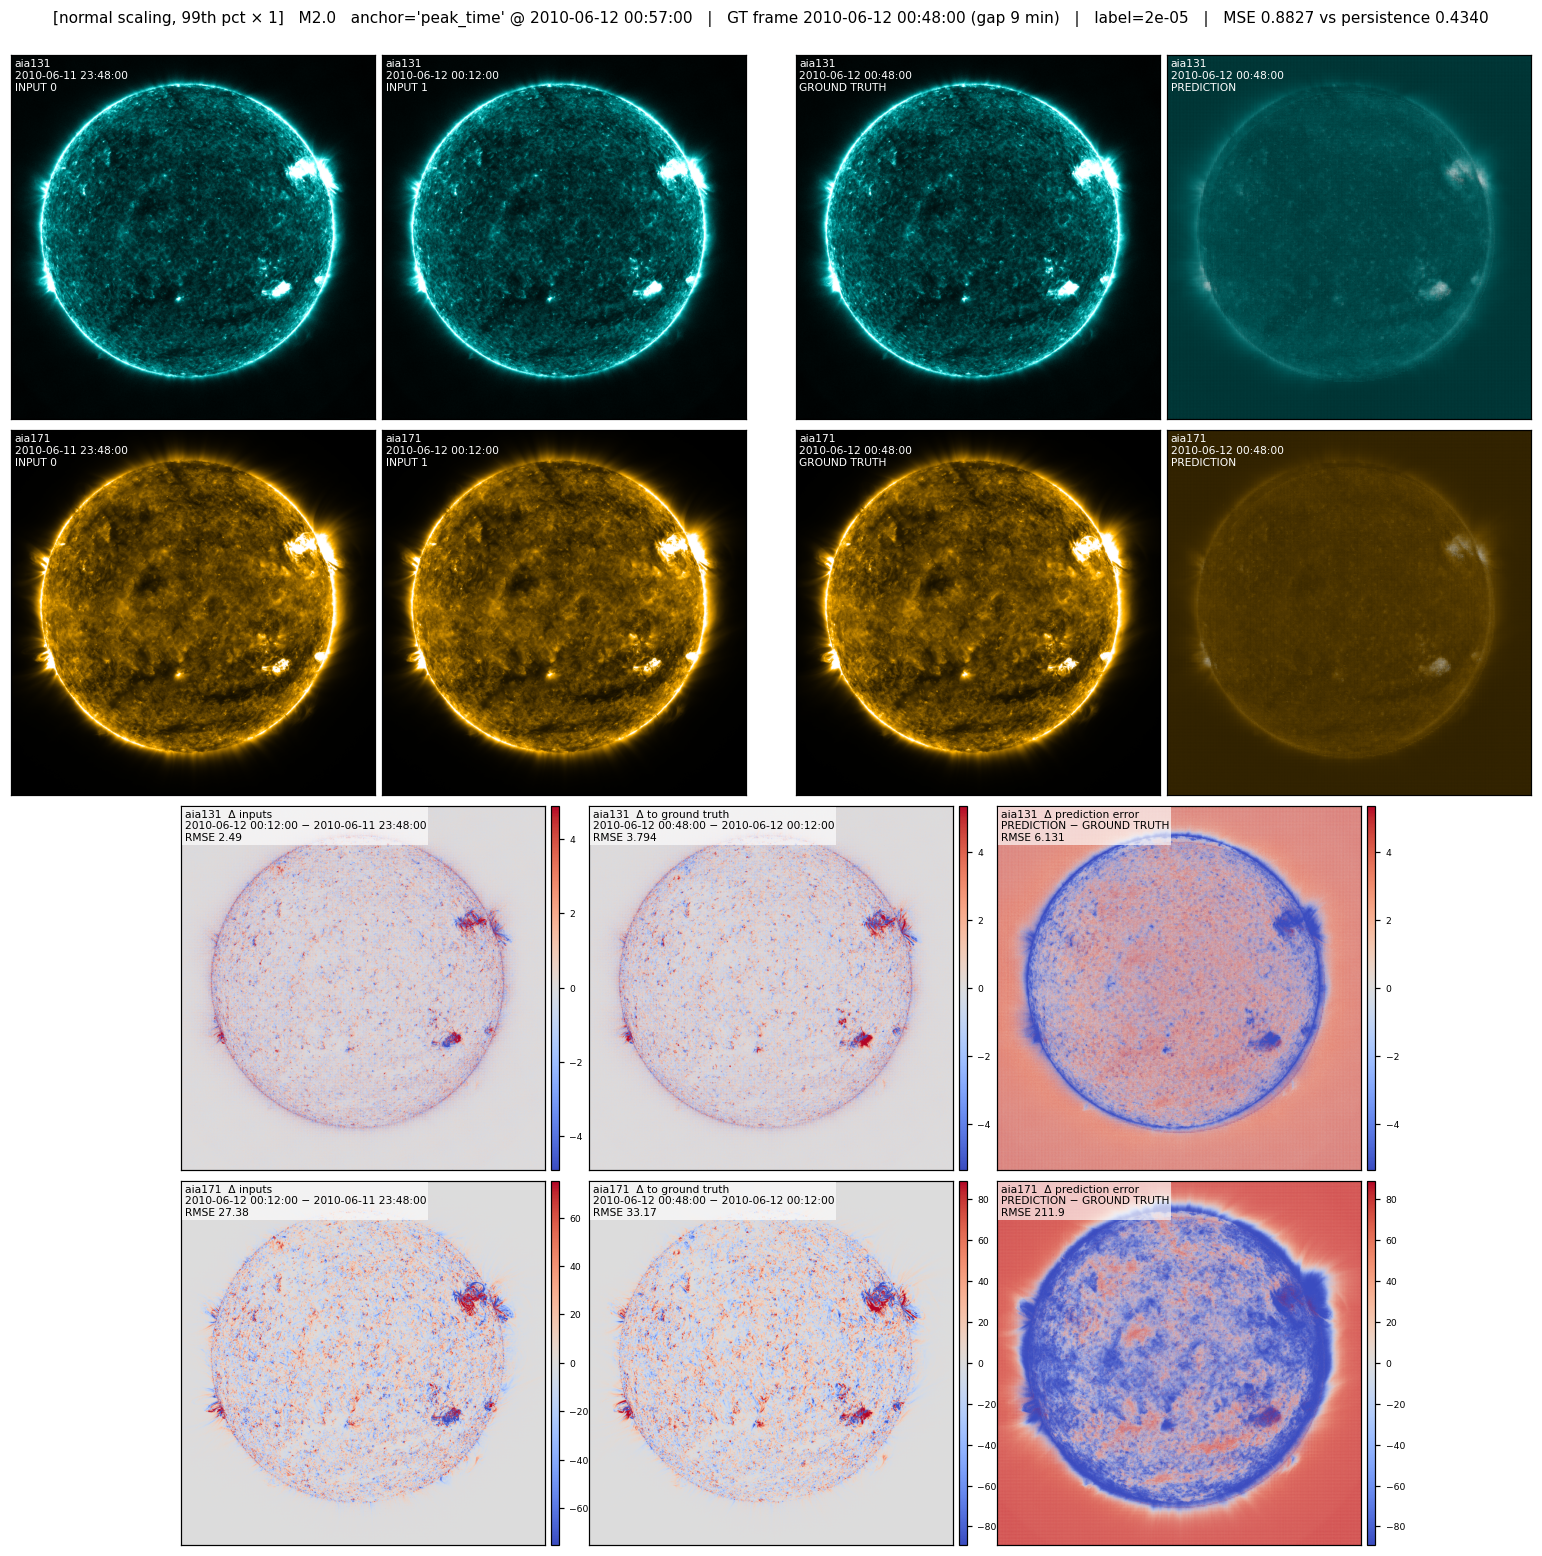

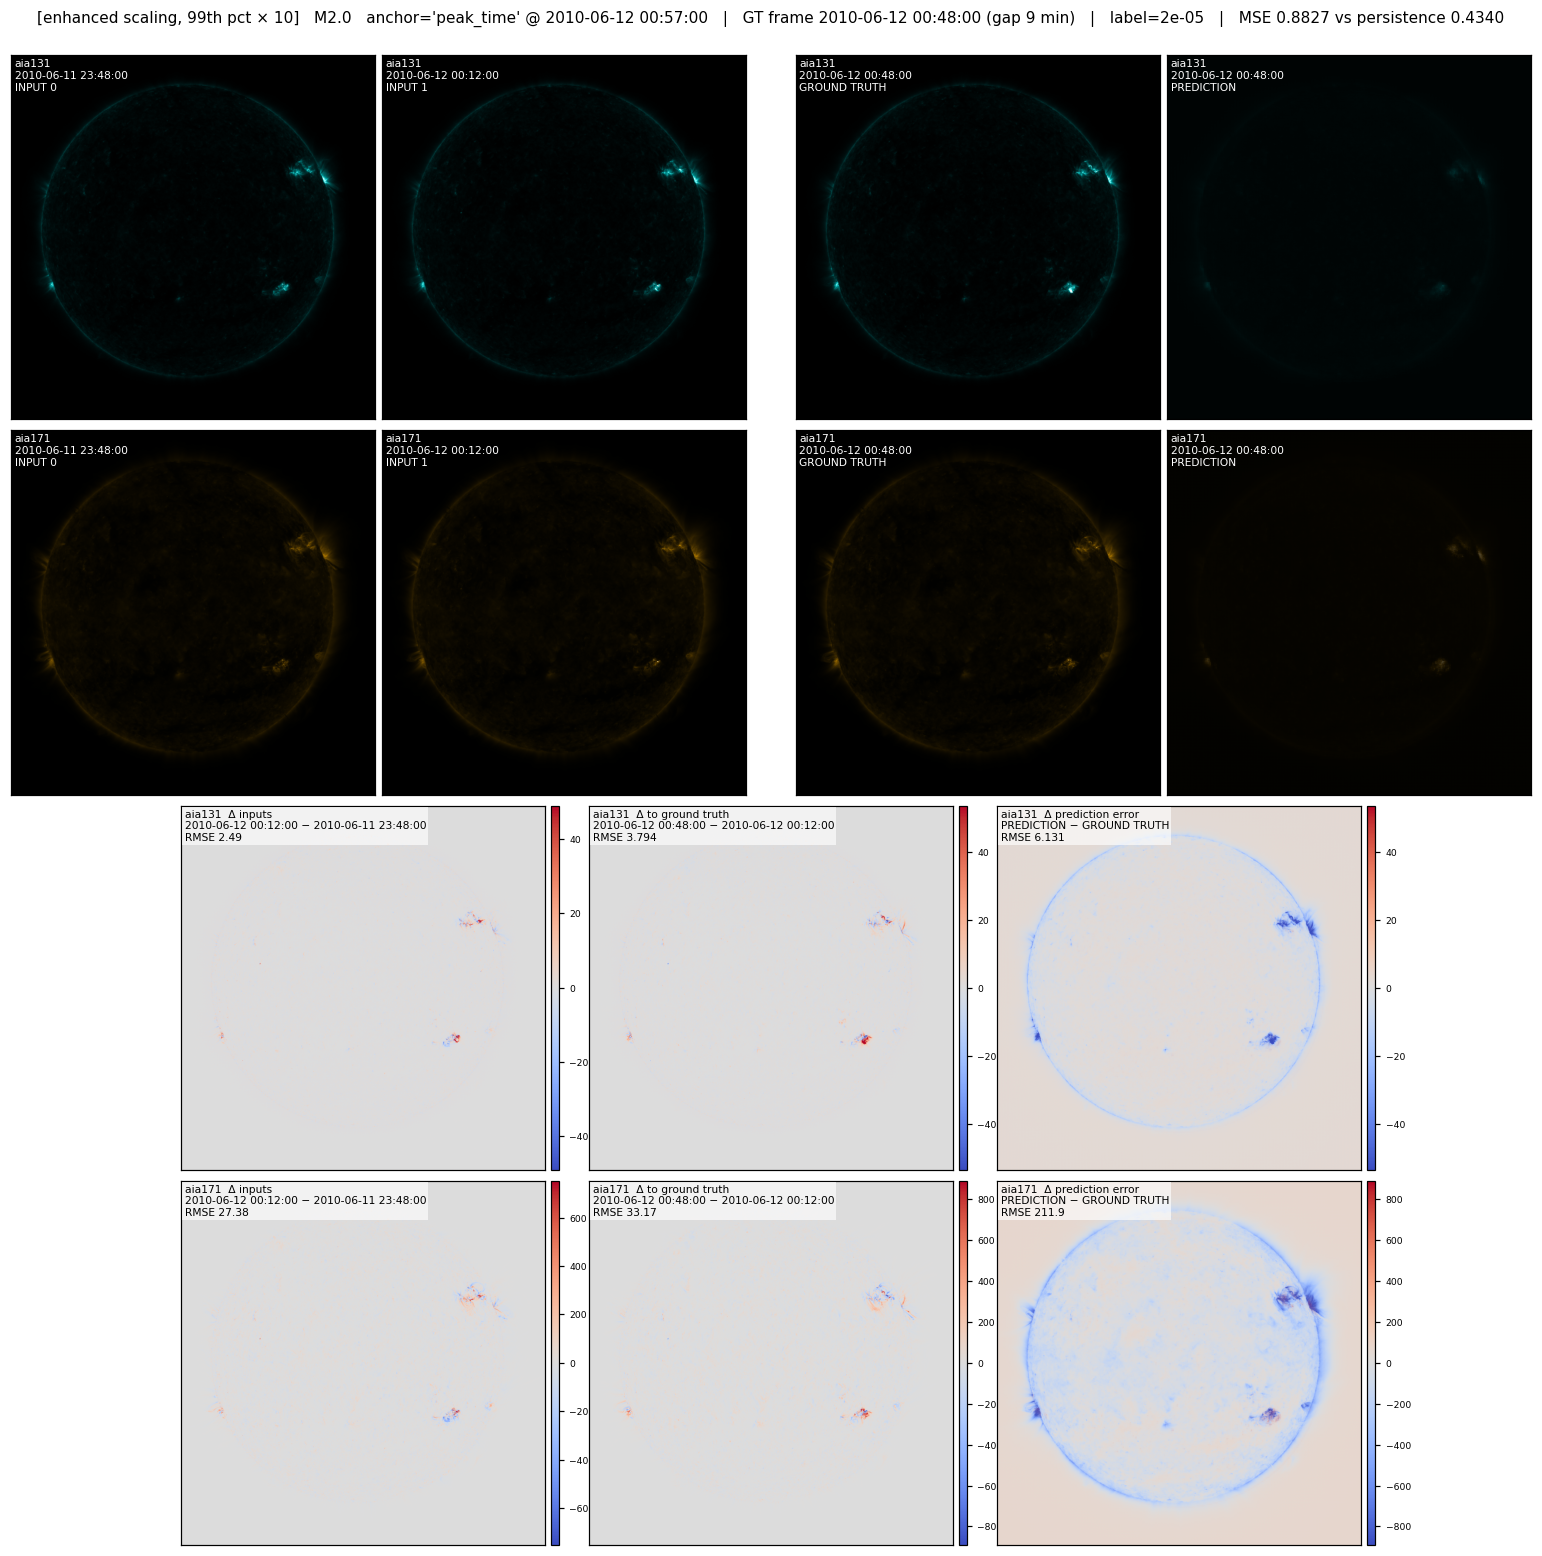

In [23]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import sunpy.visualization.colormaps as cm  # registers 'sdoaia131', 'hmimag', ...
from torch.utils.data._utils.collate import default_collate

# ==================================================================
# CONFIG FOR THIS CHECK
# ==================================================================
CHANNELS_TO_PLOT = ["aia131", "aia171"]          # one row per channel
SCALE_VERSIONS   = [("normal", 1), ("enhanced", 10)]   # 99th-pct multiplier
STRIDE           = 1     # 1 = full 4096. Set 4 to make the figure ~16x faster;
                         # inverse_transform is elementwise, so striding is exact.
SHARE_GT_PRED_SCALE = True   # see note under section 4

train_dataset = train_data_loader.dataset        # nb0's name for it
idx           = 0

channel_order = cfg.data.channels
ch_idx = {c: channel_order.index(c) for c in CHANNELS_TO_PLOT}

item = train_dataset[idx]

n_inputs = item["ts"].shape[1]
n_lead   = item["forecast"].shape[1]
assert n_lead == 1, f"this plot assumes one target frame; got {n_lead}. Set rollout_steps: 0."

# ==================================================================
# 0. RUN THE MODEL  (NEW)
# ==================================================================
# lit_model, not model: lit_model wraps the PEFT model with the trained adapters
# and head. Lightning moves it back to CPU after fit, hence the explicit .to().
lit_model = lit_model.to("cuda").eval()
with torch.no_grad(), torch.autocast("cuda", dtype=torch.bfloat16):
    _b = default_collate([item])
    _b = {k: (v.to("cuda") if torch.is_tensor(v) else v) for k, v in _b.items()}
    pred_norm = lit_model(_b)[0].float().cpu().numpy()   # (13, H, W), normalized space
del _b; torch.cuda.empty_cache()

# ==================================================================
# 1. TRUE FRAME TIMESTAMPS  (from the sample itself, not from ds_index)
# ==================================================================
reference_timestep = pd.Timestamp(train_dataset.valid_indices[idx])

# helio.py: the LAST entry of the sorted input offsets is the "now" frame.
now_offset_min = sorted(cfg.data.time_delta_input_minutes)[-1]
now_time = reference_timestep + pd.Timedelta(minutes=now_offset_min)

# time_delta_input = hours BEFORE now ; lead_time_delta = hours before now (neg = future)
input_times  = [now_time - pd.Timedelta(minutes=round(float(h) * 60))
                for h in item["time_delta_input"]]
target_times = [now_time - pd.Timedelta(minutes=round(float(h) * 60))
                for h in item["lead_time_delta"]]

# ==================================================================
# 2. PROVENANCE REPORT
# ==================================================================
row = train_dataset.df_valid_indices.iloc[idx]
anchor_col   = cfg.data.ds_time_column
anchor_event = pd.Timestamp(item["ds_index"])
gt_time      = target_times[0]
gap          = abs(gt_time - anchor_event)

print(f"FLARE EVENT      : {row['GOES_class']}   ")
print(f"  start_time     : {row['start_time']}")
print(f"  peak_time      : {row['peak_time']}")
print(f"  end_time       : {row['end_time']}")
print(' ')
print(' ')
print(f"ds_time_column = '{anchor_col}'  ->  {anchor_event}")
print(' ')
print(f"Ground Truth {gt_time}")
print(f"Reference Timestamp (helio.py anchor): {reference_timestep}")
print(f"    offset from {anchor_col:<11}: {gap}  "
      f"({gap.total_seconds()/60:.0f} min)")
print(f"    ds_index vs reference gap: {abs(reference_timestep - anchor_event)}")
print(' ')
print(' ')
print("config: ", cfg.data.time_delta_input_minutes,
      f"  | n_input_timestamps = {train_dataset.n_input_timestamps}")
print(' ')
print("source files:")
for k, ts in enumerate(input_times):
    print(f"  [input {k}] {ts}  (t{'' if k==0 else ''}={(ts-now_time).total_seconds()/60:+.0f} min from now)"
          f"\n            -> {train_dataset.index.loc[ts, 'path']}")
for k, ts in enumerate(target_times):
    print(f"  [GT    {k}] {ts}  ({(ts-now_time).total_seconds()/60:+.0f} min from now)"
          f"\n            -> {train_dataset.index.loc[ts, 'path']}")
print(' ')
print(f"Flipped?  ->  flare_dataset = {item.get('was_flipped')} "
      f"| helio = {getattr(train_dataset, 'random_vert_flip', None)}")
print(' ')

# ==================================================================
# 2b. PREDICTION QUALITY  (NEW)
# ==================================================================
# Per-channel means, then averaged: identical to the global mean (equal sizes) but
# holds only one 67 MB channel at a time instead of four 872 MB arrays.
_gt_n  = item["forecast"][:, 0]      # normalized space -- what the loss actually sees
_now_n = item["ts"][:, -1]           # persistence: copy the "now" frame forward
mse_model = float(np.mean([((pred_norm[k] - _gt_n[k]) ** 2).mean()
                           for k in range(len(channel_order))]))
mse_persist = float(np.mean([((_now_n[k] - _gt_n[k]) ** 2).mean()
                             for k in range(len(channel_order))]))
print("NORMALIZED-SPACE MSE  (all 13 channels -- comparable to train_loss/val_loss)")
print(f"  model              : {mse_model:.5f}")
print(f"  persistence        : {mse_persist:.5f}   <- copy 'now' forward, no model")
print(f"  skill vs persist.  : {1 - mse_model/mse_persist:+.1%}   (>0 = model helps)")
print(' ')
print("PER-CHANNEL RMSE, physical units")
print(f"  {'channel':<10} {'model':>12} {'persistence':>14}")
for c, n in ch_idx.items():
    rm = float(np.sqrt(((pred_norm[n] - _gt_n[n]) ** 2).mean()))
    rp = float(np.sqrt(((_now_n[n]    - _gt_n[n]) ** 2).mean()))
    print(f"  {c:<10} {rm:>12.4g} {rp:>14.4g}")
print(' ')
print(' ')

# ==================================================================
# 3. PHYSICAL-UNIT FRAMES PER CHANNEL
# ==================================================================
# Transform each FRAME once (all 13 channels at a time -- inverse_transform_data
# indexes per-channel stats, so the channel axis must stay whole), then slice the
# channels we plot out of the result.
inv, _c, S = train_dataset.inverse_transform_data, np.ascontiguousarray, STRIDE
ins_phys  = [inv(_c(item["ts"][:, t, ::S, ::S]))       for t in range(n_inputs)]
tgts_phys = [inv(_c(item["forecast"][:, l, ::S, ::S])) for l in range(n_lead)]
prds_phys = [inv(_c(pred_norm[:, ::S, ::S]))]

frames = {c: ([a[n] for a in ins_phys],
              [a[n] for a in tgts_phys],
              [a[n] for a in prds_phys]) for c, n in ch_idx.items()}

# ==================================================================
# 4. PLOTTING
# ==================================================================
def _lim(a, factor):
    nz = a[a != 0]
    return (np.percentile(nz, 99) * factor) if nz.size else 1.0

def _show(ax, img, channel, label, factor, lim=None):
    # lim=None keeps nb0's behaviour (each panel scaled to itself). Pass an explicit
    # lim to force two panels onto one scale -- required for GT vs PREDICTION, or a
    # prediction that is uniformly 10x too bright looks identical to the truth.
    if lim is None:
        lim = _lim(img, factor)
    if "hmi" not in channel:
        ax.imshow(img, cmap=f"sdo{channel}", vmin=0, vmax=lim)
        fc = "w"
    else:
        fc = "k"
        ax.imshow(img, cmap="coolwarm" if "_v" in channel else "hmimag",
                  vmin=-lim, vmax=lim)
    ax.text(0.01, 0.99, label, transform=ax.transAxes, ha="left", va="top",
            color=fc, fontsize=7)
    ax.set_xticks([]); ax.set_yticks([])

n_out   = 2 * n_lead                                  # GT columns + PRED columns
n_cols  = n_inputs + 1 + n_out                        # +1 = spacer column
w_ratios = [1] * n_inputs + [0.10] + [1] * n_out

for tag, factor in SCALE_VERSIONS:
    n_rows = len(CHANNELS_TO_PLOT) * 2                # image rows + diff rows
    panel = 3.4                                    # inches per (square) panel
    title_in = 0.42                                # inches reserved for suptitle
    fig_w = panel * (n_inputs + n_out) + panel * w_ratios[n_inputs]
    fig_h = panel * n_rows + title_in
    fig = plt.figure(figsize=(fig_w, fig_h), dpi=110)
    gs = gridspec.GridSpec(n_rows, n_cols, figure=fig,
                           width_ratios=w_ratios,
                           wspace=0.02, hspace=0.03,
                           left=0.004, right=0.996,
                           top=1 - title_in / fig_h,   # <- kills the title gap
                           bottom=0.004)
    # ---- image rows: one per channel, columns = time ----
    for r, c in enumerate(CHANNELS_TO_PLOT):
        ins, tgts, prds = frames[c]
        for t in range(n_inputs):
            _show(fig.add_subplot(gs[r, t]), ins[t], c,
                  f"{c}\n{input_times[t]}\nINPUT {t}", factor)
        for l in range(n_lead):
            gt_lim = _lim(tgts[l], factor)
            _show(fig.add_subplot(gs[r, n_inputs + 1 + l]), tgts[l], c,
                  f"{c}\n{target_times[l]}\nGROUND TRUTH", factor)
            _show(fig.add_subplot(gs[r, n_inputs + 1 + n_lead + l]), prds[l], c,
                  f"{c}\n{target_times[l]}\nPREDICTION", factor,
                  lim=gt_lim if SHARE_GT_PRED_SCALE else None)
    # ---- diff rows: centered below, layout of grid above untouched ----
    for r, c in enumerate(CHANNELS_TO_PLOT):
        ins, tgts, prds = frames[c]
        diffs = []
        if n_inputs >= 2:
            diffs.append((ins[-1] - ins[-2],
                          f"{c}  Δ inputs\n{input_times[-1]} − {input_times[-2]}", None))
        # The signal the model has to produce...
        d_signal = tgts[0] - ins[-1]
        lim_sig = np.percentile(np.abs(d_signal), 99) * factor or 1.0
        diffs.append((d_signal,
                      f"{c}  Δ to ground truth\n{target_times[0]} − {input_times[-1]}", lim_sig))
        # ...and how far off it is, on the SAME scale. Same amplitude as the panel to
        # its left => the model captured none of the change.
        diffs.append((prds[0] - tgts[0],
                      f"{c}  Δ prediction error\nPREDICTION − GROUND TRUTH", lim_sig))

        gap_u = w_ratios[n_inputs]
        n_d   = len(diffs)
        side  = (sum(w_ratios) - (n_d + gap_u * (n_d - 1))) / 2
        ratios = [side]
        for k in range(n_d):
            if k:
                ratios.append(gap_u)
            ratios.append(1)
        ratios.append(side)
        inner = gs[len(CHANNELS_TO_PLOT) + r, :].subgridspec(
            1, len(ratios), width_ratios=ratios, wspace=0)
        for k, (d, title, forced) in enumerate(diffs):
            ax = fig.add_subplot(inner[0, 2 * k + 1])
            lim = forced if forced is not None else (np.percentile(np.abs(d), 99) * factor or 1.0)
            im = ax.imshow(d, cmap="coolwarm", vmin=-lim, vmax=lim)
            ax.text(0.01, 0.99, f"{title}\nRMSE {np.sqrt((d**2).mean()):.4g}",
                    transform=ax.transAxes, ha="left", va="top",
                    fontsize=7, color="k",
                    bbox=dict(fc="w", ec="none", alpha=0.65, pad=1.5))
            ax.set_xticks([]); ax.set_yticks([])
            cax = ax.inset_axes([1.015, 0.0, 0.022, 1.0])
            cb = fig.colorbar(im, cax=cax)
            cb.ax.tick_params(labelsize=6)
    fig.suptitle(
        f"[{tag} scaling, 99th pct × {factor}]   {row['GOES_class']}   "
        f"anchor='{anchor_col}' @ {anchor_event}   |   GT frame {gt_time} "
        f"(gap {gap.total_seconds()/60:.0f} min)   |   label={float(item['ground_truth']):.4g}"
        f"   |   MSE {mse_model:.4f} vs persistence {mse_persist:.4f}",
        fontsize=10, y=0.999)
    plt.show()